In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



Using Colab cache for faster access to the 'student-performance-dataset' dataset.


In [20]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler, Binarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline



In [19]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [23]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Performance Index', axis=1),df['Performance Index'],test_size=0.2,random_state=42)

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, Binarizer

trf = ColumnTransformer([
    ('encode',
     OneHotEncoder(
         sparse_output=False,
         drop='first',
         handle_unknown='ignore'
     ),
     [2]),

    ('binarize',
     Binarizer(threshold=2),
     [4])
],
remainder='passthrough')

In [26]:
pipe=make_pipeline(trf,LinearRegression())

In [29]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2]),
                                                 ('binarize',
                                                  Binarizer(threshold=2),
                                                  [4])])),
                ('linearregression', LinearRegression())])

In [30]:
y_pred=pipe.predict(X_test)

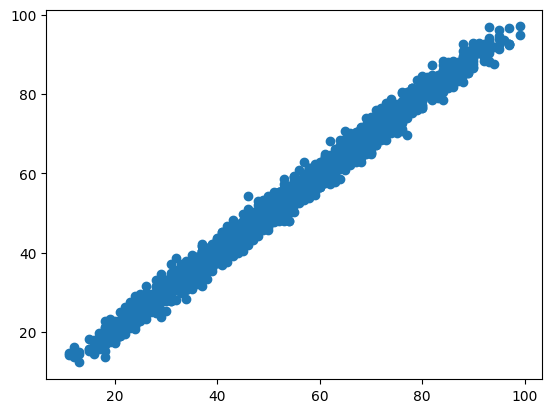

In [32]:
plt.scatter(y_test,y_pred)


plt.show()

In [37]:
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import cross_val_score


In [38]:
crossval=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')


In [40]:
crossval.mean()

np.float64(0.9883489305917215)